In [6]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from kerastuner.tuners import RandomSearch
from sklearn.metrics import mean_squared_error
from datetime import datetime, timedelta

C:\Users\ASTHAGINA DELIA P\AppData\Local\Temp\ipykernel_20328\211589628.py:9: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import RandomSearch


In [19]:
data = pd.read_csv(r"C:\Users\ASTHAGINA DELIA P\Downloads\DailyDelhiClimateTest.csv")
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)
data = data.sort_index()

print(data)

             meantemp   humidity  wind_speed  meanpressure
date                                                      
2017-01-01  15.913043  85.869565    2.743478     59.000000
2017-01-02  18.500000  77.222222    2.894444   1018.277778
2017-01-03  17.111111  81.888889    4.016667   1018.333333
2017-01-04  18.700000  70.050000    4.545000   1015.700000
2017-01-05  18.388889  74.944444    3.300000   1014.333333
...               ...        ...         ...           ...
2017-04-20  34.500000  27.500000    5.562500    998.625000
2017-04-21  34.250000  39.375000    6.962500    999.875000
2017-04-22  32.900000  40.900000    8.890000   1001.600000
2017-04-23  32.875000  27.500000    9.962500   1002.125000
2017-04-24  32.000000  27.142857   12.157143   1004.142857

[114 rows x 4 columns]


In [20]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [21]:
# Function to create a dataset with time steps
def create_dataset(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps), 0])
        y.append(data[i + time_steps, 0])
    return np.array(X), np.array(y)

# Use only the first scaled feature (meantemp) for the univariate LSTM
temp_scaled = data_scaled[:, 0:1]

time_steps = int(len(temp_scaled) * 0.2)
split_ratio = 0.8

X, y = create_dataset(temp_scaled, time_steps)

split = int(split_ratio * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


In [33]:
# Define the model builder function for Keras Tuner
def build_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('units', min_value=50, max_value=200, step=50),
                   return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(LSTM(units=hp.Int('units', min_value=50, max_value=200, step=50)))
    model.add(Dense(units=1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [32]:
# Define the tuner and perform hyperparameter search
tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5, 
    executions_per_trial=1,
    directory='keras_tuner_logs',
    project_name='temperature_prediction')

# Perform hyperparameter search
tuner.search(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[EarlyStopping(patience=3)])

Reloading Tuner from keras_tuner_logs\temperature_prediction\tuner0.json


In [31]:
# Get the best hyperparameters and build the best model
best_hp = tuner.get_best_hyperparameters()[0]

# Build the best model
best_model = tuner.hypermodel.build(best_hp)

# Train the best model with early stopping to prevent overfitting on the small climate dataset
history = best_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[EarlyStopping(patience=3)], verbose=1)

Epoch 1/100


c:\Users\ASTHAGINA DELIA P\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 466ms/step - loss: 0.1435 - val_loss: 0.5022
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0904 - val_loss: 0.3198
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.0453 - val_loss: 0.1536
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0174 - val_loss: 0.0337
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0173 - val_loss: 0.0070
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0273 - val_loss: 0.0118
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0191 - val_loss: 0.0361
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0106 - val_loss: 0.0694


In [35]:
# Predict meantemp for the test set
predictions_scaled = best_model.predict(X_test)

# Inverse transform only the first feature using the scaler fitted on all 4 columns
predictions = scaler.inverse_transform(
    np.hstack((predictions_scaled, np.zeros((predictions_scaled.shape[0], data.shape[1]-1))))
)[:, 0]

# Actual meantemp values corresponding to y_test
y_test_actual = data['meantemp'].iloc[time_steps + split:].to_numpy()

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f'Root Mean Squared Error: {rmse:.2f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Root Mean Squared Error: 4.89


In [36]:
# Predict the next 2 months
future_steps = 60  # Approx. 2 months
last_sequence = temp_scaled[-time_steps:]  # Last available univariate meantemp sequence

future_predictions = []

for _ in range(future_steps):
    next_pred_scaled = best_model.predict(last_sequence.reshape(1, time_steps, 1))
    future_predictions.append(next_pred_scaled[0, 0])
    last_sequence = np.append(last_sequence[1:], next_pred_scaled, axis=0)

future_predictions = scaler.inverse_transform(
    np.hstack((np.array(future_predictions).reshape(-1, 1),
               np.zeros((future_steps, data.shape[1] - 1))))
)[:, 0]

# Create future dates
last_date = data.index[-1]
future_dates = [last_date + timedelta(days=i) for i in range(1, future_steps + 1)]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━

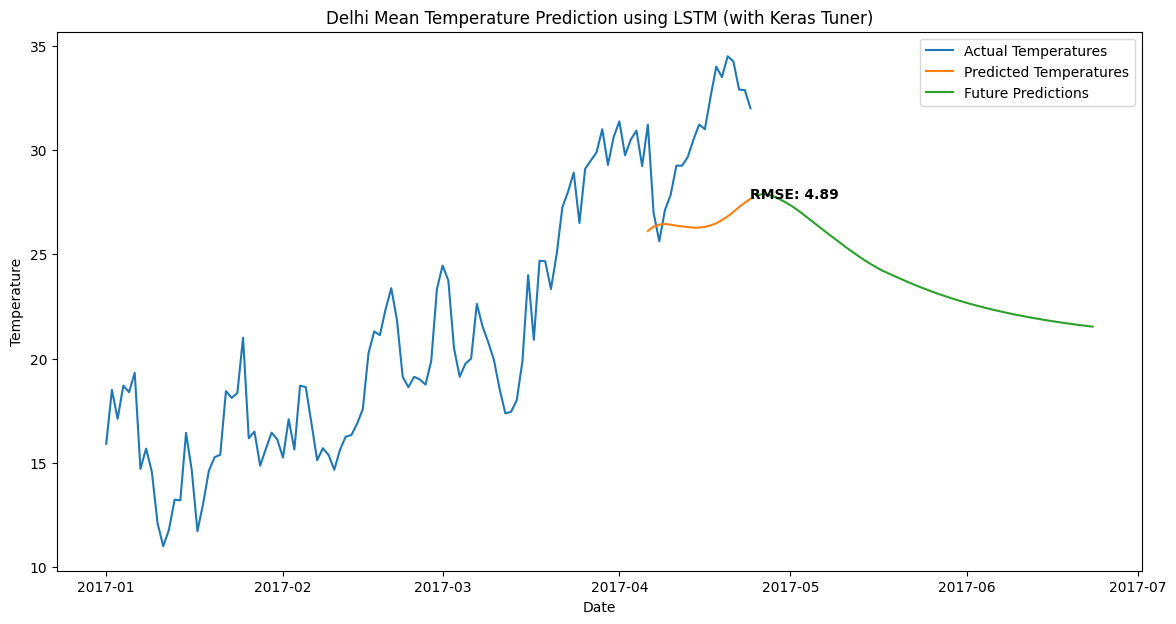

In [37]:
# Visualize the results
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['meantemp'], label='Actual Temperatures')
plt.plot(data.index[-len(predictions):], predictions, label='Predicted Temperatures')
plt.plot(future_dates, future_predictions, label='Future Predictions')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('Delhi Mean Temperature Prediction using LSTM (with Keras Tuner)')
plt.legend()

# Add RMSE to the plot
plt.text(data.index[-1], predictions[-1], f'RMSE: {rmse:.2f}', horizontalalignment='left', size='medium', color='black', weight='semibold')

plt.show()